# Human-in-the-Loop

## What is Human-in-the-Loop (HITL)?

Autonomous agents can take **real-world actions** — sending emails, issuing refunds, deleting
records, executing trades. In production we rarely want an agent to do these things unsupervised.
**Human-in-the-loop** inserts a checkpoint where a person reviews the agent's *proposed* action and
decides whether to **approve**, **reject**, or **edit** it before it actually runs.

The mechanism that makes this possible is the **interrupt**: the graph pauses mid-execution, its
full state is saved by a **checkpointer**, and control returns to the caller. Later — seconds or
days later, in the same process or a completely different one — you resume from the exact same point.
Durable pausing is why HITL and checkpointing always go together.

## Goals

This notebook shows the **low-level LangGraph primitives** for HITL. We build a `StateGraph`
by hand and gate tool execution ourselves. We'll learn:

1. `interrupt_before` — pause the graph **before** a node executes (review before action)
2. `interrupt_after` — pause **after** a node, before continuing (review results)
3. Inspecting the pending state with `get_state()`
4. **Approving** by resuming with `graph.invoke(None, config)`
5. **Rejecting / overriding** by editing state with `graph.update_state(...)`

![Human-in-the-Loop](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb0c085deffbef02f9184_human-in-the-loop1.png)

---

## LangGraph primitives vs. LangChain middleware

In [wk4 · 3.middleware/2.human_inthe_loop.ipynb](../wk4_langchain_agents_mcp/3.middleware/2.human_inthe_loop.ipynb)
we achieved the *same outcome* using the higher-level `HumanInTheLoopMiddleware` on a
`create_agent` agent. Both approaches run on the **same underlying LangGraph interrupt + checkpointer
engine** — the difference is how much you wire up yourself.

| Aspect | **LangGraph primitives** (this notebook) | **LangChain middleware** (wk4) |
|--------|------------------------------------------|--------------------------------|
| Graph construction | You build the `StateGraph` (nodes, edges, `ToolNode`) by hand | `create_agent(...)` builds the ReAct graph for you |
| Where the pause is declared | `compile(interrupt_before=["tools"])` — pauses before the **whole node** | `HumanInTheLoopMiddleware(interrupt_on={"send_email": True, ...})` — **per-tool**, opt-in |
| Granularity | All-or-nothing on a node; you filter tool calls yourself | Choose exactly which tools require approval |
| What the pause surfaces | You read `get_state()` and pick apart `tool_calls` manually | A structured `__interrupt__` payload with the proposed action + a description |
| Approve | `graph.invoke(None, config)` | `Command(resume={"decisions": [{"type": "approve"}]})` |
| Reject | `update_state(..., as_node="tools")` with a hand-crafted `ToolMessage` | `Command(resume={"decisions": [{"type": "reject", "message": ...}]})` |
| Edit the action | Manually rewrite the AI message / tool args in state | `Command(resume={"decisions": [{"type": "edit", "edited_action": {...}}]})` — built in |
| Boilerplate | More — full control over the flow | Less — the middleware standardizes approve/reject/edit |
| Best for | Custom graphs, unusual control flow, understanding the internals | Standard tool-gating on `create_agent` agents in production |

**Takeaway:** reach for `HumanInTheLoopMiddleware` when you're using `create_agent` and just need
per-tool approval with the standard approve/reject/edit decisions. Drop down to the raw
`interrupt_before` / `update_state` primitives shown here when you're building a custom graph, need
non-standard pause points, or want to understand exactly what the middleware does under the hood.


In [1]:
%run ../langchain_common.py

C:\Users\akhawaja\git\cs4603\langchain_common.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
USER_AGENT environment variable not set, consider setting it to identify your requests.


## Setup: Agent with Tools

Let's create a simple agent that can perform actions we might want to gate behind human approval.

In [2]:
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool

@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email to the specified recipient."""
    return f"Email sent to {to} with subject '{subject}'"

@tool
def search_contacts(query: str) -> str:
    """Search for a contact by name."""
    contacts = {"alice": "alice@company.com", "bob": "bob@company.com"}
    for name, email in contacts.items():
        if query.lower() in name:
            return f"Found: {name} ({email})"
    return f"No contact found for '{query}'"

tools = [send_email, search_contacts]
llm_with_tools = llm_noreason.bind_tools(tools)

In [3]:
sys_msg = SystemMessage(content="You are a helpful assistant that can search contacts and send emails.")

def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

print("Graph defined (not yet compiled)")

Graph defined (not yet compiled)


## Interrupt Before: Gate Tool Execution

By passing `interrupt_before=["tools"]` to `compile()`, the graph will **pause** before executing any tool call.

This lets us inspect what the agent wants to do and decide whether to approve it.

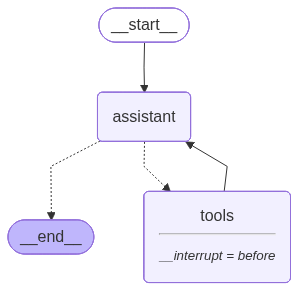

In [4]:
memory = MemorySaver()
graph = builder.compile(checkpointer=memory, interrupt_before=["tools"])

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Run the Agent — It Will Pause

When the LLM decides to call a tool, the graph stops and waits for human approval.

In [5]:
config = make_thread_config()

# Ask the agent to send an email
result = graph.invoke(
    {"messages": [HumanMessage(content="Send an email to Alice saying the meeting is at 3pm")]},
    config
)

print("Graph paused! Let's inspect what it wants to do:")
print()
last_msg = result["messages"][-1]
print(f"Agent wants to call: {last_msg.tool_calls}")

Graph paused! Let's inspect what it wants to do:

Agent wants to call: [{'name': 'send_email', 'args': {'to': 'Alice', 'subject': 'Meeting Time', 'body': 'The meeting is at 3pm.'}, 'id': 'call_23c5c887-40cf-485c-824c-16ebfde2bb13', 'type': 'tool_call'}]


## Inspect the Pending State

We can use `get_state()` to see exactly where the graph is paused and what's pending.

In [6]:
state = graph.get_state(config)
print(f"Next node to execute: {state.next}")
print(f"Number of messages so far: {len(state.values['messages'])}")
print()
print("Pending tool calls:")
for tc in state.values['messages'][-1].tool_calls:
    print(f"  Tool: {tc['name']}")
    print(f"  Args: {tc['args']}")

Next node to execute: ('tools',)
Number of messages so far: 2

Pending tool calls:
  Tool: send_email
  Args: {'to': 'Alice', 'subject': 'Meeting Time', 'body': 'The meeting is at 3pm.'}


## Approve: Resume Execution

To approve, simply invoke the graph again with `None` input — it continues from where it paused.

In [7]:
# Approve — resume execution
result = graph.invoke(None, config)

print("Execution resumed and completed!")
print()
for msg in result["messages"]:
    msg.pretty_print()

Execution resumed and completed!

================================ Human Message =================================

Send an email to Alice saying the meeting is at 3pm
================================== Ai Message ==================================
Tool Calls:
  send_email (call_23c5c887-40cf-485c-824c-16ebfde2bb13)
 Call ID: call_23c5c887-40cf-485c-824c-16ebfde2bb13
  Args:
    to: Alice
    subject: Meeting Time
    body: The meeting is at 3pm.
================================= Tool Message =================================
Name: send_email

Email sent to Alice with subject 'Meeting Time'
================================== Ai Message ==================================

The email has been sent to Alice.


LLM Own Decision Making - Overriding all rules because of the message content! Ignored tool call by itself

In [14]:
# Start a new conversation
config = make_thread_config()

result = graph.invoke(
    {"messages": [HumanMessage(content="send email bob that he is fired! subect: you are fired")]},
    config
)

last = result["messages"][-1]

print("Agent wants to send an email — pending human approval!")
print(f"Tool call: {last.tool_calls}")

Agent wants to send an email — pending human approval!
Tool call: []


## Reject: Modify the State

To reject a tool call, we can update the state — replacing the AI's tool call message with a human override.

In [11]:
# Start a new conversation
config2 = make_thread_config()

result = graph.invoke(
    {"messages": [HumanMessage(content="Send an email to Bob saying the Friday deadline has been moved up to tomorrow.")]},
    config2
)

last = result["messages"][-1]

print("Agent wants to send an email — pending human approval!")
print(f"Tool call: {last.tool_calls}")


Agent wants to send an email — pending human approval!
Tool call: [{'name': 'search_contacts', 'args': {'query': 'Bob'}, 'id': 'call_d5d95bc2-47fa-4046-961b-53cc84150ea9', 'type': 'tool_call'}]


In [9]:
from langchain_core.messages import ToolMessage

pending_tool_calls = result["messages"][-1].tool_calls
tool_call_id = pending_tool_calls[0]["id"]

# Update state with a denial message, acting as if the tools node produced it.
graph.update_state(
    config2,
    {"messages": [ToolMessage(
        content="Action denied by human reviewer. Nothing was executed. "
                "Tell the user their request was rejected.",
        tool_call_id=tool_call_id,
    )]},
    as_node="tools",  # Act as if the tools node produced this
)

# Resume — the agent will see the denial and respond accordingly.
result = graph.invoke(None, config2)

print("After rejection:")
for msg in result["messages"]:
    msg.pretty_print()


After rejection:
================================ Human Message =================================

Send an email to Bob saying the Friday deadline has been moved up to tomorrow.
================================== Ai Message ==================================
Tool Calls:
  search_contacts (call_7b3c1b43-f4b7-4d67-92f7-3694a2155442)
 Call ID: call_7b3c1b43-f4b7-4d67-92f7-3694a2155442
  Args:
    query: Bob
================================= Tool Message =================================

Action denied by human reviewer. Nothing was executed. Tell the user their request was rejected.
================================== Ai Message ==================================

I am unable to proceed with your request to send an email to Bob. The action was denied by a human reviewer.


## Edit: Change the Action's Arguments

**Reject** and **edit** share the exact same mechanics — `update_state(...)` followed by
`graph.invoke(None, config)` — but they differ in **one decisive way: does the real tool run?**

|  | **Reject** | **Edit** |
|--|-----------|----------|
| What you write into state | a **`ToolMessage`** (a fake *result*) | a **`AIMessage`** (a rewritten *request*) |
| Which node you impersonate | `as_node="tools"` | `as_node="assistant"` |
| Does the real tool execute? | **No** — you supplied the result, so the tools node is skipped | **Yes** — you only changed the *args*, and the tools node still runs |
| Net effect | Action cancelled | Action happens, but differently |

**Why the node choice matters.** The graph flows `assistant → tools → assistant`:

- **Reject** writes at the *end* of the tools step (`as_node="tools"`), so the graph believes the
  tool already produced output and **jumps past** the real tool back to the assistant.
- **Edit** rewrites the pending `AIMessage` at the *assistant* step (`as_node="assistant"`) while
  we are **still paused before the tools node** — so on resume the tools node **genuinely executes**,
  just with the corrected arguments.

**The key trick:** reuse the **same message `id`** so the edited `AIMessage` *replaces* the pending
one instead of appending a new message. Below, the agent proposes `search_contacts(query="Bob")`
and the human edits it to `query="alice"` — after resuming you'll see the tool return **alice's**
contact, proving the real tool ran with the edited args.


In [15]:
# Start a fresh conversation for the edit demo
config3 = make_thread_config()

result = graph.invoke(
    {"messages": [HumanMessage(content="Look up Bob's contact details.")]},
    config3,
)

ai_msg = result["messages"][-1]
assert ai_msg.tool_calls, "Expected a pending tool call to edit — re-run this cell."
print("Agent proposed (pending human review):")
for tc in ai_msg.tool_calls:
    print(f"  {tc['name']}(args={tc['args']})")


Agent proposed (pending human review):
  search_contacts(args={'query': 'Bob'})


In [16]:
from langchain_core.messages import AIMessage

# The agent proposed search_contacts(query="Bob"). The human overrides the ARGS.
ai_msg = result["messages"][-1]
original_call = ai_msg.tool_calls[0]

# Build a replacement AIMessage carrying the EDITED tool call.
# Reusing the SAME message id means this REPLACES the pending message
# (rather than appending a second one). We also keep the same tool_call id.
edited_ai = AIMessage(
    content=ai_msg.content,
    id=ai_msg.id,
    tool_calls=[{
        "name": original_call["name"],
        "args": {**original_call["args"], "query": "alice"},  # human corrects Bob -> alice
        "id": original_call["id"],
        "type": "tool_call",
    }],
)

# Write it as if the *assistant* produced it. We are still paused BEFORE the tools
# node, so on resume the REAL tool executes — with the corrected arguments.
graph.update_state(config3, {"messages": [edited_ai]}, as_node="assistant")

# Resume. Unlike reject (where we faked the result), here the tool actually runs.
result = graph.invoke(None, config3)

print("After edit — the tool ran with the corrected args:")
for msg in result["messages"]:
    msg.pretty_print()


After edit — the tool ran with the corrected args:
================================ Human Message =================================

Look up Bob's contact details.
================================== Ai Message ==================================
Tool Calls:
  search_contacts (call_3ee60bcf-9b3c-49ee-a160-9bd9288bb6bc)
 Call ID: call_3ee60bcf-9b3c-49ee-a160-9bd9288bb6bc
  Args:
    query: alice
================================= Tool Message =================================
Name: search_contacts

Found: alice (alice@company.com)
================================== Ai Message ==================================

I found a contact named Alice, but I couldn't find a contact named Bob. Would you like me to search for someone else?


## Key Takeaways

| Pattern | Use Case |
|---------|----------|
| `interrupt_before=["node"]` | Pause before a node executes (review before action) |
| `interrupt_after=["node"]` | Pause after a node (review results before continuing) |
| `graph.invoke(None, config)` | Resume execution (used by **approve**, **reject**, and **edit**) |
| `graph.get_state(config)` | Inspect current pause point |
| **Approve** | `invoke(None, config)` — resume with state untouched; the real tool runs |
| **Reject** | `update_state(..., as_node="tools")` with a `ToolMessage` — fakes the result, tool is **skipped** |
| **Edit** | `update_state(..., as_node="assistant")` with a rewritten `AIMessage` (same `id`) — tool **runs with new args** |

The three decisions (**approve / reject / edit**) are exactly what `HumanInTheLoopMiddleware`
exposes as a `decisions` payload in wk4 — here you build them yourself from `update_state` + resume.

This pattern is **essential** for production agents where actions have real-world consequences (sending emails, making purchases, modifying databases).